# Wing print free flight images preprocessing

The wing print free flight images are organized in four recordings sessions and need to be merged into meaningful data sets before they fed into the experiments.

## Download data

Our data set is hosted at Hugging Face. You can use this code to directly download it. If you have already downloaded the data set, point the DATA_DIR constant to it.

You will need around 75 GB of free space on your drive.

In [1]:
from huggingface_hub import snapshot_download
import os

# point this constant to the folder you want to download the data into
DATA_DIR = r"D:\wingprint_paper\free_flight"

#local_dir = snapshot_download(
#    repo_id="j-dey/bats-wing-print-free-flight",
#    repo_type="dataset",
#    local_dir=DATA_DIR
#)


## Define data sets

This section defines all data sub sets that will be generated for the experiments. A "balanced" set has a minimum and maximum number of approaches per individual. Those are generally used as training sets.

Note that all data sets are generated in one go, accumulating to about 300 GB of storage (including the raw data sets).

In [2]:
from collections import defaultdict
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns
import shutil
from tqdm.contrib import tzip
from tqdm.notebook import tqdm

import utils

utils.seed_everything()

sns.set_theme()

INPUT_FOLDER = os.path.join(DATA_DIR, "raw_datasets")
MERGED_FOLDER = os.path.join(DATA_DIR, "merged_datasets")
FINALIZED_FOLDER = os.path.join(DATA_DIR, "finalized_datasets")

DATASETS = [
    # for closed set baseline experiments and tuning the rejection threshold
    {
        "name": "A1_balanced",
        "input": "A1",
        "min_approaches": 15,
        "max_approaches": 50,
    },
    {
        "name": "A1_complete",
        "input": "A1",
        "min_approaches": 1,
        "max_approaches": 5000, # arbitrary large number
    },
    {
        "name": "A2_balanced",
        "input": "A2",
        "min_approaches": 15,
        "max_approaches": 50,
    },
    {
        "name": "A2_complete",
        "input": "A2",
        "min_approaches": 1,
        "max_approaches": 5000, # arbitrary large number
    },
    {
        "name": "B1_balanced",
        "input": "B1",
        "min_approaches": 15,
        "max_approaches": 50,
    },
    {
        "name": "B1_complete",
        "input": "B1",
        "min_approaches": 1,
        "max_approaches": 5000, # arbitrary large number
    },
    {
        "name": "B2_balanced",
        "input": "B2",
        "min_approaches": 15,
        "max_approaches": 50,
    },
    {
        "name": "B2_complete",
        "input": "B2",
        "min_approaches": 1,
        "max_approaches": 5000, # arbitrary large number
    },
    # for predicting unknown data
    {
        "name": "A_balanced",
        "input": "A",
        "min_approaches": 15,
        "max_approaches": 50,
    },
    {
        "name": "B_complete",
        "input": "B",
        "min_approaches": 1,
        "max_approaches": 5000, # arbitrary large number
    },
]

## Merge data sets into intermediate sets

The recording sessions are now merged into meaningful data sets based on the (already harmonized) animal IDs.

In [3]:
merged_datasets = []

for dataset in DATASETS:
    if len(dataset["input"]) == 1:
        if dataset['input'] not in merged_datasets:
            merged_datasets.append(dataset['input'])

for ds_name in merged_datasets:
    shutil.rmtree(os.path.join(MERGED_FOLDER, ds_name), ignore_errors=True)

    print(f"generate dataset {ds_name} in {os.path.join(MERGED_FOLDER, ds_name)}")

    for input_set in tqdm(glob.glob(os.path.join(INPUT_FOLDER, f'{ds_name}*'))):
        subset_name = os.path.basename(input_set)

        for class_folder in tqdm(glob.glob(os.path.join(input_set, '*'))):
            id = int(os.path.basename(class_folder))

            for approach_folder in glob.glob(os.path.join(class_folder, '*')):
                target = os.path.join(MERGED_FOLDER, ds_name, str(id), f"{subset_name}_{os.path.basename(approach_folder)}")

                shutil.copytree(approach_folder, target)

generate dataset A in D:\wingprint_paper\free_flight\merged_datasets\A


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

generate dataset B in D:\wingprint_paper\free_flight\merged_datasets\B


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

## Calculate some data set statistics

Number of individuals: 58
Average approaches per bat: 116.0 ± 186.0
Least approaches of a single bat: 1
Most approaches of a single bat: 987
Average images per approach: 20.0 ± 9.0
Total images: 133175


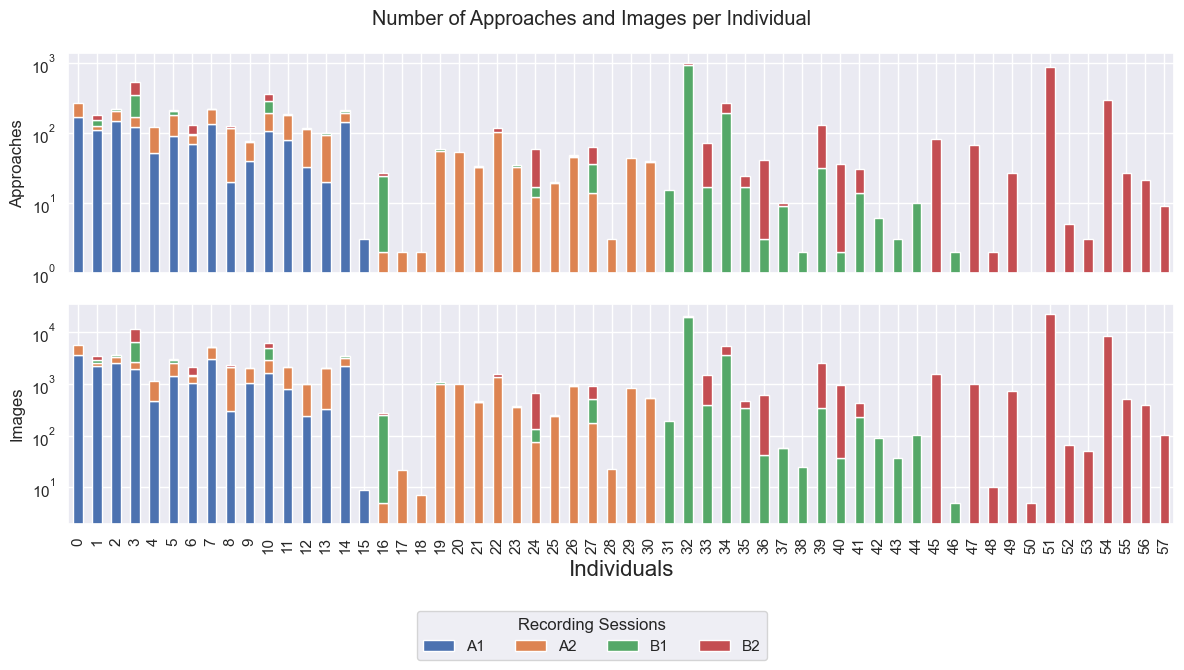

In [ ]:
SCALE = "log"

individuals = {}
imgs_by_approach = []

for dataset in glob.glob(os.path.join(MERGED_FOLDER, '*')):
    for class_path in glob.glob(os.path.join(dataset, '*')):
        id = int(os.path.basename(class_path))

        approaches = glob.glob(os.path.join(class_path, '*'))

        approaches_by_session = defaultdict(int)
        imgs_by_session = defaultdict(int)

        for approach in approaches:
            session_name = os.path.basename(approach).split("_")[0]

            num_imgs = len(glob.glob(os.path.join(approach, '*.png')))

            approaches_by_session[session_name] += 1
            imgs_by_session[session_name] += num_imgs
            
            imgs_by_approach.append(num_imgs)

        if id not in individuals:
            individuals[id] = (approaches_by_session, imgs_by_session)
        else:
            overall_approaches_by_session, overall_imgs_by_session = individuals[id]
            
            for session, count in approaches_by_session.items():
                overall_approaches_by_session[session] += int(count)

            for session, count in imgs_by_session.items():
                overall_imgs_by_session[session] += int(count)

print(f"Number of individuals: {len(individuals)}")

names = []
approach_counts = []
image_counts = []

for name, (approaches_by_session, imgs_by_session) in individuals.items():
    names.append(name)
    approach_counts.append(sum(approaches_by_session.values()))
    image_counts.append(sum(imgs_by_session.values()))

print(f"Average approaches per bat: {np.round(np.mean(approach_counts))} ± {np.round(np.std(approach_counts))}")
print(f"Least approaches of a single bat: {np.min(approach_counts)}")
print(f"Most approaches of a single bat: {np.max(approach_counts)}")
print(f"Average images per approach: {np.round(np.mean(imgs_by_approach))} ± {np.round(np.std(imgs_by_approach))}")
print(f"Total images: {np.sum(imgs_by_approach)}")

approach_data = {key: dict(x) for key, (x, _) in individuals.items()}

approach_df = pd.DataFrame.from_dict(approach_data, orient='index')
approach_df = approach_df.sort_index()

img_data = {key: dict(x) for key, (_, x) in individuals.items()}

img_df = pd.DataFrame.from_dict(img_data, orient='index')
img_df = img_df.sort_index()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

a = approach_df.plot(kind='bar', stacked=True, ax=axes[0], legend=False)
a.set_yscale(SCALE)
a.set_xlabel("Individual", fontsize=16)
a.set_ylabel("Approaches")

i = img_df.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
i.set_yscale(SCALE)
i.set_xlabel("Individuals", fontsize=16)
i.set_ylabel("Images")

plt.setp(axes[1].get_xticklabels(), rotation=90)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Recording Sessions', loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Number of Approaches and Images per Individual", fontdict = {'fontsize' : 16})

plt.tight_layout()
plt.savefig("Free_Flight_Dataset_Stats.pdf", bbox_inches="tight")

## Generate final sub sets

In [5]:
for dataset in tqdm(DATASETS):
    # seed every time so that the output stays the same even if some datasets are skipped
    utils.seed_everything()

    ds_name = dataset["name"]
    input_ds = dataset["input"]

    if len(input_ds) > 1:
        input = os.path.join(INPUT_FOLDER, dataset["input"])
    else:
        input = os.path.join(MERGED_FOLDER, dataset["input"])

    output = os.path.join(FINALIZED_FOLDER, ds_name)
    shutil.rmtree(output, ignore_errors=True)

    min_approaches = dataset["min_approaches"]
    max_approaches = dataset["max_approaches"]

    samples = []
    labels = []

    class_folders = glob.glob(os.path.join(input, "*"))

    for class_folder in class_folders:
        individual_ID = int(os.path.basename(class_folder))

        approach_folders = glob.glob(os.path.join(class_folder, "*"))

        if len(approach_folders) >= min_approaches:
            selected_folders = random.sample(approach_folders, min(len(approach_folders), max_approaches))

            for folder in selected_folders:
                samples.append(os.path.basename(folder))
                labels.append(individual_ID)

    os.makedirs(output)

    for folder, individual_ID in tzip(samples, labels):
        src = os.path.join(input, str(individual_ID), folder)
        dst = os.path.join(output, str(individual_ID), folder)

        shutil.copytree(src, dst)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/662 [00:00<?, ?it/s]

  0%|          | 0/1340 [00:00<?, ?it/s]

  0%|          | 0/1030 [00:00<?, ?it/s]

  0%|          | 0/1466 [00:00<?, ?it/s]

...

  0%|          | 0/1697 [00:00<?, ?it/s]

  0%|          | 0/795 [00:00<?, ?it/s]

  0%|          | 0/2215 [00:00<?, ?it/s]

  0%|          | 0/1111 [00:00<?, ?it/s]

  0%|          | 0/3912 [00:00<?, ?it/s]